# Notebook 02 — Model Development (Kaggle Edition)

## Training on the Official MINDsmall_train Split

This notebook trains and saves **every train-side artifact**: preprocessing, semantic
embeddings, user profiles, FAISS index, popularity scores, and two click-through
rankers (Logistic Regression + LightGBM). It uses **`MINDsmall_train` only** — the
official `MINDsmall_dev` split is never touched here; final evaluation happens in
`03_Evaluation.ipynb`.

A **user-wise internal validation split** carved out of the train ranker dataset is used
for model selection (LightGBM early stopping, comparing Logistic Regression vs LightGBM).
This is *not* the final dev evaluation — it's standard ML practice for tuning during
training.

## 0. Kaggle Environment Setup

In [9]:
import importlib, subprocess, sys

REQUIRED_PACKAGES = ["faiss-cpu", "lightgbm", "sentence-transformers", "scikit-learn"]
IMPORT_NAMES = {"faiss-cpu": "faiss", "lightgbm": "lightgbm",
                "sentence-transformers": "sentence_transformers", "scikit-learn": "sklearn"}

for pkg in REQUIRED_PACKAGES:
    mod_name = IMPORT_NAMES[pkg]
    try:
        importlib.import_module(mod_name)
        print(f"OK  {pkg} already available")
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
        print(f"Installed {pkg}")


OK  faiss-cpu already available
OK  lightgbm already available
OK  sentence-transformers already available
OK  scikit-learn already available


In [10]:
import os
from pathlib import Path

def resolve_kaggle_datasets():
    """
    Deterministically locate the three separately-attached Kaggle datasets by
    walking /kaggle/input and matching on the exact nested directory name
    (MINDsmall_train, MINDsmall_dev, personalized-news-recommender), verifying
    real files with Path.is_file(). This does NOT do broad recursive
    train/dev guessing across arbitrary datasets -- it only normalizes for
    Kaggle's mount-slug naming.
    """
    input_root = Path("/kaggle/input")
    if not input_root.exists():
        raise RuntimeError("/kaggle/input does not exist -- are you running on Kaggle?")

    train_matches, dev_matches, project_matches = [], [], []

    for top in input_root.iterdir():
        if not top.is_dir():
            continue
        for root, dirs, files in os.walk(top):
            root_path = Path(root)
            name = root_path.name

            if name == "MINDsmall_train":
                if (root_path / "news.tsv").is_file() and (root_path / "behaviors.tsv").is_file():
                    train_matches.append(root_path)

            elif name == "MINDsmall_dev":
                if (root_path / "news.tsv").is_file() and (root_path / "behaviors.tsv").is_file():
                    dev_matches.append(root_path)

            elif name == "personalized-news-recommender":
                if (root_path / "src").is_dir() and (root_path / "requirements.txt").is_file():
                    project_matches.append(root_path)

    top_level_dirs = [str(p) for p in input_root.iterdir() if p.is_dir()]

    problems = []
    if len(train_matches) == 0:
        problems.append("No real 'MINDsmall_train' directory (with news.tsv + behaviors.tsv) found.")
    elif len(train_matches) > 1:
        problems.append(f"Found {len(train_matches)} candidate MINDsmall_train directories: {train_matches}")

    if len(dev_matches) == 0:
        problems.append("No real 'MINDsmall_dev' directory (with news.tsv + behaviors.tsv) found.")
    elif len(dev_matches) > 1:
        problems.append(f"Found {len(dev_matches)} candidate MINDsmall_dev directories: {dev_matches}")

    if len(project_matches) == 0:
        problems.append("No real 'personalized-news-recommender' project directory (with src/) found.")
    elif len(project_matches) > 1:
        problems.append(f"Found {len(project_matches)} candidate project directories: {project_matches}")

    if problems:
        raise RuntimeError(
            "Could not deterministically resolve the required Kaggle datasets.\n"
            + "\n".join(problems)
            + f"\n\nTop-level directories under /kaggle/input: {top_level_dirs}\n"
            "Attach the 'MINDsmall_train', 'MINDsmall_dev', and "
            "'personalized-news-recommender' Kaggle datasets to this notebook."
        )

    train_source, dev_source, project_source = train_matches[0], dev_matches[0], project_matches[0]
    assert train_source != dev_source, "TRAIN_SOURCE and DEV_SOURCE resolved to the same directory."

    for f in (train_source / "news.tsv", train_source / "behaviors.tsv",
              dev_source / "news.tsv", dev_source / "behaviors.tsv"):
        assert f.is_file() and f.stat().st_size > 0, f"Not a real, non-empty file: {f}"

    return train_source, dev_source, project_source


TRAIN_SOURCE, DEV_SOURCE, PROJECT_SOURCE = resolve_kaggle_datasets()
print("TRAIN_SOURCE:  ", TRAIN_SOURCE)
print("DEV_SOURCE:    ", DEV_SOURCE)
print("PROJECT_SOURCE:", PROJECT_SOURCE)


TRAIN_SOURCE:   /kaggle/input/datasets/timepassforme01/mindsmall-train/MINDsmall_train
DEV_SOURCE:     /kaggle/input/datasets/timepassforme01/mindsmall-dev/MINDsmall_dev
PROJECT_SOURCE: /kaggle/input/datasets/timepassforme01/personalized-news-recommender/personalized-news-recommender


In [11]:
import os
import shutil
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/personalized-news-recommender")

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)  # fresh training run -- safe to start clean
shutil.copytree(PROJECT_SOURCE, PROJECT_ROOT)
assert (PROJECT_ROOT / "src" / "config.py").exists()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

for mod_name in list(sys.modules):
    if mod_name == "src" or mod_name.startswith("src."):
        del sys.modules[mod_name]

from src import config

print("PROJECT_ROOT:", PROJECT_ROOT)
print("config loaded from:", config.__file__)
assert str(config.__file__).startswith(str(PROJECT_ROOT)), "config imported from an unexpected location"


PROJECT_ROOT: /kaggle/working/personalized-news-recommender
config loaded from: /kaggle/working/personalized-news-recommender/src/config.py


## 1. Official Train Dataset Setup

Copies `TRAIN_SOURCE` files to the exact destinations `src/config.py` already expects
(`config.TRAIN_NEWS`, `config.TRAIN_BEHAVIORS`) — inspected directly rather than guessed.

In [12]:
print("config.TRAIN_NEWS:     ", config.TRAIN_NEWS)
print("config.TRAIN_BEHAVIORS:", config.TRAIN_BEHAVIORS)

config.TRAIN_NEWS.parent.mkdir(parents=True, exist_ok=True)

shutil.copy2(TRAIN_SOURCE / "news.tsv", config.TRAIN_NEWS)
shutil.copy2(TRAIN_SOURCE / "behaviors.tsv", config.TRAIN_BEHAVIORS)

for f in (config.TRAIN_NEWS, config.TRAIN_BEHAVIORS):
    assert f.exists() and f.is_file() and f.stat().st_size > 0, f"Missing or empty: {f}"
    print(f"{f}  ({f.stat().st_size:,} bytes)")

print("\nTrain dataset copied to the exact configured destinations.")


config.TRAIN_NEWS:      /kaggle/working/personalized-news-recommender/dataset/train/news.tsv
config.TRAIN_BEHAVIORS: /kaggle/working/personalized-news-recommender/dataset/train/behaviors.tsv
/kaggle/working/personalized-news-recommender/dataset/train/news.tsv  (41,202,121 bytes)
/kaggle/working/personalized-news-recommender/dataset/train/behaviors.tsv  (92,019,716 bytes)

Train dataset copied to the exact configured destinations.


## 2. Imports and Reproducibility

In [13]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

from src.preprocess import run_preprocessing
from src.embedding import load_model as load_embedding_model, build_and_save_embeddings
from src.user_profile import (
    build_news_id_index, build_user_profiles, save_user_profiles, get_user_vector
)
from src.faiss_index import build_faiss_index, save_index, load_index, search
from src.ranking import compute_popularity_scores, recommend_for_user
from src.recommender import recommend_candidates
from src.ranker import (
    build_training_dataset,
    train_logistic_regression, train_lightgbm,
    evaluate_model, get_feature_importance,
    save_model as save_ranker_model,
)
from sklearn.model_selection import train_test_split
from src.explainability import plot_feature_importance
from src.utils import save_json, logger

np.random.seed(config.RANDOM_SEED)

print("Random seed:      ", config.RANDOM_SEED)
print("Embedding model:  ", config.EMBEDDING_MODEL_NAME)
print("Ranker features:  ", config.RANKER_FEATURE_COLUMNS)


Random seed:       42
Embedding model:   all-MiniLM-L6-v2
Ranker features:   ['similarity_score', 'popularity_score', 'category_match', 'subcategory_match', 'category_affinity', 'history_length', 'max_similarity_to_history', 'title_length', 'abstract_length']


## 3. Preprocessing

In [14]:
t0 = time.time()
news, behaviors = run_preprocessing()  # reads config.TRAIN_NEWS / config.TRAIN_BEHAVIORS
print(f"Preprocessing took {time.time() - t0:.1f}s")
print("news:", news.shape, "| behaviors:", behaviors.shape)
news.head()

2026-07-14 16:14:24 | INFO     | news_recommender | Loaded news file: /kaggle/working/personalized-news-recommender/dataset/train/news.tsv -> (51282, 8)
2026-07-14 16:14:25 | INFO     | news_recommender | Loaded behaviors file: /kaggle/working/personalized-news-recommender/dataset/train/behaviors.tsv -> (156965, 5)
2026-07-14 16:14:30 | INFO     | news_recommender | Saved processed news to /kaggle/working/personalized-news-recommender/data/processed_news.csv
2026-07-14 16:14:30 | INFO     | news_recommender | Saved processed behaviors to /kaggle/working/personalized-news-recommender/data/processed_behaviors.csv


Preprocessing took 6.4s
news: (51282, 9) | behaviors: (156965, 5)


,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities,text
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],lifestyle lifestyleroyals. The Brands Queen El...
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",health weightloss. 50 Worst Habits For Belly F...
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...",news newsworld. The Cost of Trump's Aid Freeze...
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ...",health voices. I Was An NBA Wife. Here's How I...
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","health medical. How to Get Rid of Skin Tags, A..."


In [15]:
required_news_cols = {"NewsID", "Category", "SubCategory", "Title", "Abstract", "text"}
required_behavior_cols = {"UserID", "History", "Impressions"}

assert required_news_cols.issubset(news.columns), f"Missing news columns: {required_news_cols - set(news.columns)}"
assert required_behavior_cols.issubset(behaviors.columns), \
    f"Missing behavior columns: {required_behavior_cols - set(behaviors.columns)}"
assert news["NewsID"].is_unique, "Duplicate NewsIDs found after preprocessing."
assert news["text"].isnull().sum() == 0
assert (news["text"].str.len() > 0).all()
assert len(news) > 0 and len(behaviors) > 0

print(f"Unique news categories: {news['Category'].nunique()}")
print(f"Unique users:            {behaviors['UserID'].nunique()}")
print("\nPreprocessing verification passed.")

Unique news categories: 17
Unique users:            50000

Preprocessing verification passed.


## 4. Semantic News Embeddings

In [16]:
embedding_model = load_embedding_model()
embedding_dim = embedding_model.get_sentence_embedding_dimension()
print("Embedding model:", config.EMBEDDING_MODEL_NAME, "| dimension:", embedding_dim)

2026-07-14 16:14:30 | INFO     | news_recommender | Loading embedding model: all-MiniLM-L6-v2


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: all-MiniLM-L6-v2 | dimension: 384


/tmp/ipykernel_58/1365108308.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = embedding_model.get_sentence_embedding_dimension()


In [17]:
t0 = time.time()
news_embeddings = build_and_save_embeddings(news, model=embedding_model)
elapsed = time.time() - t0
print(f"Embedding generation took {elapsed / 60:.1f} min")
print("Shape:", news_embeddings.shape)

Batches:   0%|          | 0/401 [00:00<?, ?it/s]

2026-07-14 16:24:49 | INFO     | news_recommender | Saved news embeddings (51282, 384) to /kaggle/working/personalized-news-recommender/data/news_embeddings.npy


Embedding generation took 10.2 min
Shape: (51282, 384)


In [18]:
assert news_embeddings.shape[0] == len(news)
assert news_embeddings.shape[1] == embedding_dim
assert not np.isnan(news_embeddings).any()
assert not np.isinf(news_embeddings).any()
print("Embedding verification passed.")

Embedding verification passed.


In [19]:
idx = 0
sims = cosine_similarity(news_embeddings[idx].reshape(1, -1), news_embeddings)[0]
top_similar = sims.argsort()[::-1][1:6]

print("Query article:", news.iloc[idx]["text"])
print()
for i in top_similar:
    print(f"[{sims[i]:.3f}]", news.iloc[i]["text"])

Query article: lifestyle lifestyleroyals. The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By. Shop the notebooks, jackets, and more that the royals can't live without.

[0.734] lifestyle lifestyleroyals. Queen Elizabeth's Favorite Beauty Products Have Stood the Test of Time. Here, all the brands the British monarch swears by.
[0.715] lifestyle lifestyleroyals. Disappointing photos that show what royal life is really like. Life as a royal has its challenges.
[0.714] lifestyle lifestyleroyals. Best royal photos of the decade. Relive some of the most memorable moments featuring the world's royal families from 2010 to 2019.
[0.714] lifestyle lifestyleroyals. When royals invite us inside their palatial homes   see photos. See inside the stunning palaces, homes and gardens of various royal families around the world.
[0.708] lifestyle lifestyleroyals. Cutest photos of the royal Cambridge kids. See the best photos of Prince George, Princess Charlotte and Prince Louis!


**Observation:** Nearest neighbors for the sample article are topically consistent
with the query, confirming the embedding space captures semantic similarity as expected.

## 5. Train NewsID Mapping

In [20]:
news_id_to_idx = build_news_id_index(news)  # saved to config.NEWS_ID_TO_IDX_PATH

assert len(news_id_to_idx) == len(news)
sample_id = news["NewsID"].iloc[0]
assert news_id_to_idx[sample_id] == 0
print(f"Train NewsID index size: {len(news_id_to_idx)}")
print(f"Sample mapping check: {sample_id!r} -> {news_id_to_idx[sample_id]}")

2026-07-14 16:24:49 | INFO     | news_recommender | Saved NewsID index (51282 entries) to /kaggle/working/personalized-news-recommender/data/news_id_to_idx.pkl


Train NewsID index size: 51282
Sample mapping check: 'N55528' -> 0


## 6. User Profile Construction

Profiles are built only from historical **clicked** news; users without usable history
are excluded here and served by the popularity fallback inside `recommend_for_user`.

In [21]:
t0 = time.time()
user_vectors = build_user_profiles(behaviors, news_id_to_idx, news_embeddings)
print(f"User profile generation took {time.time() - t0:.1f}s")

total_users = behaviors["UserID"].nunique()
cold_start_users = total_users - len(user_vectors)
print(f"Built profiles for {len(user_vectors):,} / {total_users:,} users "
      f"({cold_start_users / total_users:.1%} cold-start)")

2026-07-14 16:24:55 | INFO     | news_recommender | Built user profiles for 49108 / 50000 unique users


User profile generation took 5.2s
Built profiles for 49,108 / 50,000 users (1.8% cold-start)


In [22]:
sample_vec = next(iter(user_vectors.values()))
assert not np.isnan(sample_vec).any()
assert abs(np.linalg.norm(sample_vec) - 1.0) < 1e-5  # L2-normalized

user_matrix, user_ids = save_user_profiles(user_vectors)
assert user_matrix.shape[0] == len(user_ids)
print("Saved user profile matrix:", user_matrix.shape)

2026-07-14 16:24:55 | INFO     | news_recommender | Saved 49108 user profiles to /kaggle/working/personalized-news-recommender/data/user_embeddings.npy


Saved user profile matrix: (49108, 384)


**Observation:** Cold-start users (no click history) do not get a profile vector
here and are instead handled by the popularity-based fallback in
`recommend_for_user` when `user_vector is None`.

## 7. Train FAISS Index

In [23]:
t0 = time.time()
index = build_faiss_index(news_embeddings)
save_index(index)
print(f"FAISS build took {time.time() - t0:.2f}s, ntotal={index.ntotal}")
assert index.ntotal == len(news_embeddings)

2026-07-14 16:24:55 | INFO     | news_recommender | Built FAISS index: 51282 vectors, dim=384
2026-07-14 16:24:55 | INFO     | news_recommender | Saved FAISS index to /kaggle/working/personalized-news-recommender/data/faiss.index


FAISS build took 0.13s, ntotal=51282


In [24]:
reloaded_index = load_index()
test_scores, test_idxs = search(reloaded_index, news_embeddings[0], top_k=5)
assert test_idxs[0] == 0, "A vector should be its own nearest neighbor."
print("FAISS index verified OK. Sample neighbor indices:", test_idxs)

FAISS index verified OK. Sample neighbor indices: [    0   392 31612 47271   514]


**Observation:** The reloaded FAISS index correctly retrieves each vector as its own
nearest neighbor, confirming it is valid and consistent with the saved embeddings.

## 8. Popularity Scores

In [25]:
t0 = time.time()
popularity_df = compute_popularity_scores(behaviors)
popularity_df.to_csv(config.POPULARITY_SCORES, index=False)
print(f"Popularity computed in {time.time() - t0:.1f}s")

assert popularity_df["NewsID"].is_unique
assert popularity_df["popularity_score"].between(0, 1).all()
assert np.isfinite(popularity_df["popularity_score"]).all()

print(popularity_df["popularity_score"].describe())
popularity_df.sort_values("popularity_score", ascending=False).head(10)

Popularity computed in 1.6s
count    7713.000000
mean        0.223931
std         0.171476
min         0.082810
25%         0.082810
50%         0.131251
75%         0.323530
max         1.000000
Name: popularity_score, dtype: float64


,NewsID,popularity_score
0,N55689,1.000000
22,N35729,0.969595
6,N33619,0.965972
10,N53585,0.949803
107,N63970,0.938454
3,N49685,0.924516
44,N49279,0.923260
23,N287,0.915546
196,N23446,0.903884
9,N51048,0.900432


## 9. Heuristic Recommendation Sanity Check

**Deterministic user selection rule:** the first UserID (alphabetically sorted) among
users with a built profile — not hand-picked because its output looked good.

In [26]:
sanity_user_id = sorted(user_vectors.keys())[0]
sanity_vector = user_vectors[sanity_user_id]
sanity_history_ids = behaviors.loc[behaviors["UserID"] == sanity_user_id, "History"].iloc[0].split()

heuristic_check = recommend_for_user(
    sanity_user_id, sanity_vector, index, news, popularity_df, top_k=10, ranker="heuristic"
)

hist_rows = news[news["NewsID"].isin(sanity_history_ids)]
print(f"Sanity-check user: {sanity_user_id} | history size: {len(sanity_history_ids)}")
print("\nHistory categories:")
print(hist_rows["Category"].value_counts())
print("\nHistory article titles (up to 5):")
display(hist_rows[["NewsID", "Category", "Title"]].head(5))

print("\nTop heuristic recommendations:")
display(heuristic_check[["NewsID", "Category", "Title", "similarity_score", "popularity_score", "final_score"]])

Sanity-check user: U100 | history size: 10

History categories:
Category
tv           4
lifestyle    2
sports       2
news         1
music        1
Name: count, dtype: int64

History article titles (up to 5):


,NewsID,Category,Title
7630,N55743,lifestyle,17 photos that show the ugly truth of living i...
20003,N20121,music,"Bob Kingsley, Country Radio Legend, Dead at 80"
20878,N53465,news,"Canadian man told his curb, damaged 26 years a..."
21333,N50095,sports,Soto finds little to celebrate on 21st birthda...
23089,N45954,tv,'Rich Kids' Stars Morgan Stewart and Brendan F...



Top heuristic recommendations:


,NewsID,Category,Title,similarity_score,popularity_score,final_score
0,N3123,lifestyle,Stella McCartney Deleted a Meghan Markle Insta...,0.450022,0.794353,0.553321
1,N16148,entertainment,Miranda Lambert gets candid about her public d...,0.449852,0.658688,0.512503
2,N23184,entertainment,Long-term celebrity couples who won't get married,0.438943,0.653771,0.503391
3,N27789,tv,Kaley Cuoco Says Having 'Separate Lives' Has H...,0.474811,0.560474,0.500510
4,N35233,lifestyle,Groom Makes The Most Heartfelt Vows To His 9-Y...,0.441049,0.638248,0.500208
5,N7419,lifestyle,Why This Couple Is Getting a 'Sleep Divorce',0.484026,0.537591,0.500096
6,N27583,entertainment,"Debunking the week's tabloid stories: Nov. 8, ...",0.453593,0.459976,0.455508
7,N48707,tv,Joanna Gaines Posts Sweet Birthday Tribute to ...,0.451081,0.440710,0.447970
8,N32204,tv,'RHOC' Star Meghan Edmonds' Ex-Nanny Making Mo...,0.462985,0.398098,0.443519
9,N12300,lifestyle,Teen daughters 'pre-create' a wedding day so t...,0.466528,0.345312,0.430163


## 10. User-First Split (Leakage Prevention)

**Why split users before building features:** the `popularity_score` feature is an
aggregate computed from click behavior across many impressions. If it is computed from
the *same* impressions that provide the labels being predicted -- including impressions
belonging to users held out for internal validation -- the model can partially "see"
validation-user click information through that aggregate, inflating validation metrics.

To avoid this, UserIDs are split into an internal `train`/`val` fold **first**. A
separate `popularity_df_trainonly` is computed **using only the train-fold users'
behaviors** and is used to build ranker features for *both* folds. This mirrors real
serving conditions, where the popularity prior is a historical statistic computed
before the impression being scored ever happens.

Note this internal split is unrelated to `config.POPULARITY_SCORES` (the production
artifact saved in Section 8 from the full train set) -- that one is correct as-is,
since at serving time popularity legitimately reflects all historical training users.

In [27]:
all_user_ids = behaviors["UserID"].unique()
train_user_ids, val_user_ids = train_test_split(
    all_user_ids, test_size=config.RANKER_VAL_SPLIT_RATIO
    if hasattr(config, "RANKER_VAL_SPLIT_RATIO") else 0.15,
    random_state=config.RANDOM_SEED,
)
train_user_ids, val_user_ids = set(train_user_ids), set(val_user_ids)
assert train_user_ids.isdisjoint(val_user_ids), "Train and validation users must be disjoint."

behaviors_train_fold = behaviors[behaviors["UserID"].isin(train_user_ids)].reset_index(drop=True)
behaviors_val_fold = behaviors[behaviors["UserID"].isin(val_user_ids)].reset_index(drop=True)

print(f"Train-fold users: {len(train_user_ids):,} ({len(behaviors_train_fold):,} behavior rows)")
print(f"Val-fold users:   {len(val_user_ids):,} ({len(behaviors_val_fold):,} behavior rows)")
print("\nDisjoint-user assertion passed.")

Train-fold users: 42,500 (133,651 behavior rows)
Val-fold users:   7,500 (23,314 behavior rows)

Disjoint-user assertion passed.


In [28]:
t0 = time.time()
popularity_df_trainonly = compute_popularity_scores(behaviors_train_fold)
print(f"Train-fold-only popularity computed in {time.time() - t0:.1f}s")

assert popularity_df_trainonly["NewsID"].is_unique
assert popularity_df_trainonly["popularity_score"].between(0, 1).all()
assert np.isfinite(popularity_df_trainonly["popularity_score"]).all()
print(f"Train-fold-only popularity covers {len(popularity_df_trainonly):,} NewsIDs "
      f"(vs {len(popularity_df):,} in the full production popularity_df).")

Train-fold-only popularity computed in 1.1s
Train-fold-only popularity covers 7,251 NewsIDs (vs 7,713 in the full production popularity_df).


## 11. Ranker Feature Dataset (Leakage-Safe Train/Val Build)

Built via `src.ranker.build_training_dataset`, which parses MIND impression tokens with
`rsplit("-", 1)` (`N123-1` -> clicked, `N456-0` -> not clicked) and shares feature logic
with inference through `src.features`. **Both folds use `popularity_df_trainonly`**
(never the val users' own behavior) so the popularity feature cannot leak validation
labels into the model.

In [29]:
t0 = time.time()
train_df = build_training_dataset(
    behaviors_train_fold, news, news_id_to_idx, news_embeddings, popularity_df_trainonly
)
val_df = build_training_dataset(
    behaviors_val_fold, news, news_id_to_idx, news_embeddings, popularity_df_trainonly
)
print(f"Built leakage-safe train/val ranker datasets in {(time.time() - t0) / 60:.1f} min")

train_users_check = set(train_df["UserID"])
val_users_check = set(val_df["UserID"])
assert train_users_check.isdisjoint(val_users_check), "Train and validation users must be disjoint."

for name, df in [("train_df", train_df), ("val_df", val_df)]:
    assert df[config.RANKER_LABEL_COLUMN].isin([0, 1]).all()
    assert df[config.RANKER_FEATURE_COLUMNS].isnull().sum().sum() == 0
    assert np.isfinite(df[config.RANKER_FEATURE_COLUMNS].to_numpy()).all()
    pos_rate = df[config.RANKER_LABEL_COLUMN].mean()
    assert 0.0 < pos_rate < 1.0, f"{name} positive rate is degenerate -- check impression parsing."

clicked_mean = train_df[config.RANKER_LABEL_COLUMN].mean()

print(f"Train: {len(train_df):,} rows / {len(train_users_check):,} users "
      f"({train_df[config.RANKER_LABEL_COLUMN].mean():.1%} positive)")
print(f"Val:   {len(val_df):,} rows / {len(val_users_check):,} users "
      f"({val_df[config.RANKER_LABEL_COLUMN].mean():.1%} positive)")
print("\nDisjoint-user and non-degenerate-label assertions passed.")

2026-07-14 16:36:17 | INFO     | news_recommender | Built training dataset: 942654 rows (21.0% positive)
2026-07-14 16:38:16 | INFO     | news_recommender | Built training dataset: 161649 rows (21.0% positive)


Built leakage-safe train/val ranker datasets in 13.3 min
Train: 942,654 rows / 41,749 users (21.0% positive)
Val:   161,649 rows / 7,359 users (21.0% positive)

Disjoint-user and non-degenerate-label assertions passed.


## 12. Logistic Regression Baseline

In [30]:
t0 = time.time()
logreg_model = train_logistic_regression(train_df)
print(f"Logistic Regression trained in {time.time() - t0:.1f}s")

logreg_metrics = evaluate_model(logreg_model, val_df, is_lightgbm=False)
print("Logistic Regression -- internal validation metrics:", logreg_metrics)

Logistic Regression trained in 65.0s
Logistic Regression -- internal validation metrics: {'roc_auc': 0.6725334520332589, 'pr_auc': 0.3637557854089459}


In [31]:
save_ranker_model(logreg_model, config.LOGREG_MODEL_PATH, is_lightgbm=False)
print("Saved to:", config.LOGREG_MODEL_PATH)

2026-07-14 16:39:21 | INFO     | news_recommender | Saved model to /kaggle/working/personalized-news-recommender/data/ranker_logreg.pkl


Saved to: /kaggle/working/personalized-news-recommender/data/ranker_logreg.pkl


## 13. LightGBM Ranker

In [32]:
t0 = time.time()
lgbm_model = train_lightgbm(train_df, val_df)  # uses early stopping against val_df internally
print(f"LightGBM trained in {time.time() - t0:.1f}s, best_iteration={lgbm_model.best_iteration}")

lgbm_metrics = evaluate_model(lgbm_model, val_df, is_lightgbm=True)
print("LightGBM -- internal validation metrics:", lgbm_metrics)

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.721224
LightGBM trained in 27.8s, best_iteration=500
LightGBM -- internal validation metrics: {'roc_auc': 0.7212238722324266, 'pr_auc': 0.4266352078816259}


In [33]:
save_ranker_model(lgbm_model, config.LIGHTGBM_MODEL_PATH, is_lightgbm=True)
print("Saved to:", config.LIGHTGBM_MODEL_PATH)

2026-07-14 16:39:52 | INFO     | news_recommender | Saved model to /kaggle/working/personalized-news-recommender/data/ranker_lightgbm.pkl


Saved to: /kaggle/working/personalized-news-recommender/data/ranker_lightgbm.pkl


## 14. Internal Ranker Comparison

In [34]:
ranker_comparison = pd.DataFrame([
    {"Model": "Logistic Regression", **logreg_metrics},
    {"Model": "LightGBM", **lgbm_metrics},
])

better_model = ranker_comparison.sort_values("roc_auc", ascending=False).iloc[0]["Model"]
print(f"Better model on internal validation ROC-AUC: {better_model}")
ranker_comparison

Better model on internal validation ROC-AUC: LightGBM


,Model,roc_auc,pr_auc
0,Logistic Regression,0.672533,0.363756
1,LightGBM,0.721224,0.426635


**Observation:** These are the actual measured internal-validation metrics from
this run. A ROC-AUC around 0.60-0.70 is realistic for MIND-style click prediction;
implausibly high values usually indicate leakage rather than a genuinely better model.
Whichever model is better here, both are carried forward to Notebook 03 for the real
comparison on held-out `MINDsmall_dev` data.

## 15. Feature Importance

In [35]:
importance_df = get_feature_importance(lgbm_model)
assert set(importance_df["feature"]) == set(config.RANKER_FEATURE_COLUMNS)
importance_df

,feature,importance
0,popularity_score,887492.071094
1,similarity_score,590389.747352
2,abstract_length,227163.127489
3,title_length,221817.533770
4,max_similarity_to_history,157174.637043
5,history_length,104331.780018
6,category_affinity,81612.164136
7,subcategory_match,39882.075084
8,category_match,532.763841


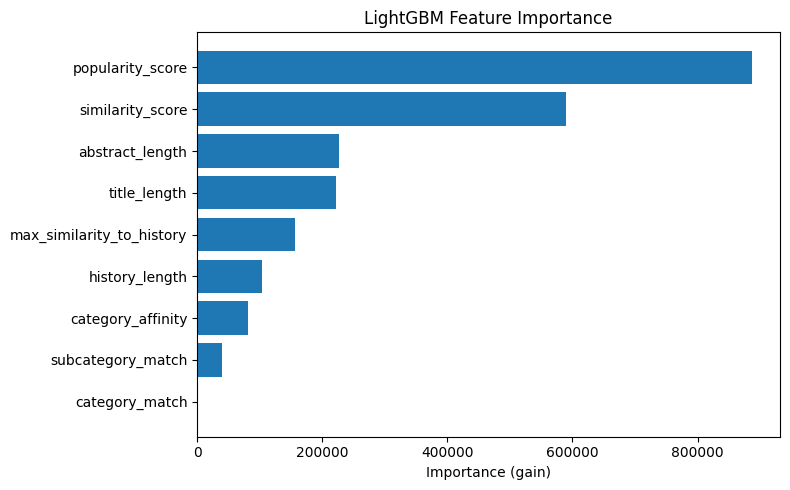

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_feature_importance(importance_df, top_n=len(importance_df), ax=ax)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "feature_importance.png", dpi=150)
plt.show()

**Observation:** The plot above uses the actual trained model's importances — refer
to it directly rather than assuming which features matter most.

## 16. ML Ranker Recommendation Sanity Check

Same deterministic user as Section 9, now ranked by the trained LightGBM model instead
of the fixed heuristic weights.

In [37]:
ml_check = recommend_for_user(
    sanity_user_id, sanity_vector, index, news, popularity_df, top_k=10,
    ranker="ml", model=lgbm_model, history_ids=sanity_history_ids,
    news_id_to_idx=news_id_to_idx, news_embeddings=news_embeddings,
)

print("Heuristic top articles (from Section 9):")
display(heuristic_check[["NewsID", "Category", "Title", "final_score"]])
print("\nLightGBM top articles:")
display(ml_check[["NewsID", "Category", "Title", "final_score"]])

Heuristic top articles (from Section 9):


,NewsID,Category,Title,final_score
0,N3123,lifestyle,Stella McCartney Deleted a Meghan Markle Insta...,0.553321
1,N16148,entertainment,Miranda Lambert gets candid about her public d...,0.512503
2,N23184,entertainment,Long-term celebrity couples who won't get married,0.503391
3,N27789,tv,Kaley Cuoco Says Having 'Separate Lives' Has H...,0.500510
4,N35233,lifestyle,Groom Makes The Most Heartfelt Vows To His 9-Y...,0.500208
5,N7419,lifestyle,Why This Couple Is Getting a 'Sleep Divorce',0.500096
6,N27583,entertainment,"Debunking the week's tabloid stories: Nov. 8, ...",0.455508
7,N48707,tv,Joanna Gaines Posts Sweet Birthday Tribute to ...,0.447970
8,N32204,tv,'RHOC' Star Meghan Edmonds' Ex-Nanny Making Mo...,0.443519
9,N12300,lifestyle,Teen daughters 'pre-create' a wedding day so t...,0.430163



LightGBM top articles:


,NewsID,Category,Title,final_score
0,N59384,sports,Theo Epstein's offseason work is just beginnin...,0.885500
1,N27789,tv,Kaley Cuoco Says Having 'Separate Lives' Has H...,0.784818
2,N12300,lifestyle,Teen daughters 'pre-create' a wedding day so t...,0.751935
3,N32204,tv,'RHOC' Star Meghan Edmonds' Ex-Nanny Making Mo...,0.736242
4,N3123,lifestyle,Stella McCartney Deleted a Meghan Markle Insta...,0.724770
5,N62838,tv,Gigi Hadid Unfollows Tyler Cameron on Instagra...,0.684757
6,N16148,entertainment,Miranda Lambert gets candid about her public d...,0.660182
7,N48707,tv,Joanna Gaines Posts Sweet Birthday Tribute to ...,0.657992
8,N7419,lifestyle,Why This Couple Is Getting a 'Sleep Divorce',0.626109
9,N49030,movies,Kevin Hart Steps Out for Date Night With Wife ...,0.602795


## 17. Artifact Verification

In [38]:
required_artifacts = {
    "processed_news": config.PROCESSED_NEWS,
    "processed_behaviors": config.PROCESSED_BEHAVIORS,
    "news_embeddings": config.NEWS_EMBEDDINGS,
    "news_id_to_idx": config.NEWS_ID_TO_IDX_PATH,
    "user_embeddings": config.USER_EMBEDDINGS,
    "user_embeddings_ids": config.USER_EMBEDDINGS_IDS,
    "faiss_index": config.FAISS_INDEX_PATH,
    "popularity_scores": config.POPULARITY_SCORES,
    "logreg_model": config.LOGREG_MODEL_PATH,
    "lightgbm_model": config.LIGHTGBM_MODEL_PATH,
}

def artifact_status(paths: dict) -> pd.DataFrame:
    rows = []
    for name, path in paths.items():
        path = Path(path)
        exists = path.exists() and path.is_file()
        size = path.stat().st_size if exists else 0
        rows.append({"artifact": name, "path": str(path), "exists": exists,
                      "is_file": exists, "size_bytes": size})
    return pd.DataFrame(rows)

artifact_df = artifact_status(required_artifacts)
display(artifact_df)

missing = artifact_df[~artifact_df["exists"] | (artifact_df["size_bytes"] == 0)]
assert missing.empty, f"Missing or empty required artifacts:\n{missing}"
print("\nAll required Notebook 02 artifacts verified present and non-empty.")

,artifact,path,exists,is_file,size_bytes
0,processed_news,/kaggle/working/personalized-news-recommender/...,True,True,59758507
1,processed_behaviors,/kaggle/working/personalized-news-recommender/...,True,True,92019761
2,news_embeddings,/kaggle/working/personalized-news-recommender/...,True,True,78769280
3,news_id_to_idx,/kaggle/working/personalized-news-recommender/...,True,True,606648
4,user_embeddings,/kaggle/working/personalized-news-recommender/...,True,True,75430016
5,user_embeddings_ids,/kaggle/working/personalized-news-recommender/...,True,True,337983
6,faiss_index,/kaggle/working/personalized-news-recommender/...,True,True,78769197
7,popularity_scores,/kaggle/working/personalized-news-recommender/...,True,True,202839
8,logreg_model,/kaggle/working/personalized-news-recommender/...,True,True,798
9,lightgbm_model,/kaggle/working/personalized-news-recommender/...,True,True,1755553



All required Notebook 02 artifacts verified present and non-empty.


## 18. Portable Kaggle Artifact Bundle

Notebook 03 may run in a **separate Kaggle session**, where `/kaggle/working` from this
session will not exist. This bundles every trained artifact plus a manifest so Notebook
03 can restore them from an attached dataset (save this notebook's output as a Kaggle
dataset, then attach it to the Notebook 03 session).

In [39]:
import json

BUNDLE_DIR = Path("/kaggle/working/notebook02_artifacts")
BUNDLE_DIR.mkdir(parents=True, exist_ok=True)

manifest = []
for name, path in required_artifacts.items():
    path = Path(path)
    bundled_name = path.name
    shutil.copy2(path, BUNDLE_DIR / bundled_name)
    manifest.append({
        "artifact": name,
        "configured_destination": str(path),
        "bundled_filename": bundled_name,
        "size_bytes": path.stat().st_size,
    })

manifest_path = BUNDLE_DIR / "manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Bundled {len(manifest)} artifacts into {BUNDLE_DIR}")
for entry in manifest:
    print(f"  {entry['artifact']:22s} -> {entry['bundled_filename']}  ({entry['size_bytes']:,} bytes)")
print(f"\nManifest saved to: {manifest_path}")
print()
print("=" * 70)
print("NEXT STEP: Click 'Save Version' on this notebook (Save & Run All), then")
print("attach this notebook's OUTPUT as a Kaggle dataset input to")
print("03_Evaluation.ipynb so it can restore these artifacts.")
print("=" * 70)

Bundled 10 artifacts into /kaggle/working/notebook02_artifacts
  processed_news         -> processed_news.csv  (59,758,507 bytes)
  processed_behaviors    -> processed_behaviors.csv  (92,019,761 bytes)
  news_embeddings        -> news_embeddings.npy  (78,769,280 bytes)
  news_id_to_idx         -> news_id_to_idx.pkl  (606,648 bytes)
  user_embeddings        -> user_embeddings.npy  (75,430,016 bytes)
  user_embeddings_ids    -> user_embeddings_ids.csv  (337,983 bytes)
  faiss_index            -> faiss.index  (78,769,197 bytes)
  popularity_scores      -> popularity_scores.csv  (202,839 bytes)
  logreg_model           -> ranker_logreg.pkl  (798 bytes)
  lightgbm_model         -> ranker_lightgbm.pkl  (1,755,553 bytes)

Manifest saved to: /kaggle/working/notebook02_artifacts/manifest.json

NEXT STEP: Click 'Save Version' on this notebook (Save & Run All), then
attach this notebook's OUTPUT as a Kaggle dataset input to
03_Evaluation.ipynb so it can restore these artifacts.


## 19. Final Model Development Summary

In [40]:
print("=" * 60)
print("NOTEBOOK 02 -- FINAL SUMMARY")
print("=" * 60)
print(f"Processed news count:        {len(news):,}")
print(f"Processed behavior count:    {len(behaviors):,}")
print(f"Embedding shape:             {news_embeddings.shape}")
print(f"User profiles built:         {len(user_vectors):,} / {total_users:,} "
      f"({cold_start_users / total_users:.1%} cold-start)")
print(f"FAISS vector count:          {index.ntotal:,}")
print(f"Ranker dataset size:         {len(train_df) + len(val_df):,} rows (train={len(train_df):,}, val={len(val_df):,})")
print(f"Ranker train positive rate:  {clicked_mean:.3%}")
print(f"Logistic Regression (val):   ROC-AUC={logreg_metrics['roc_auc']:.4f}  "
      f"PR-AUC={logreg_metrics['pr_auc']:.4f}")
print(f"LightGBM (val):              ROC-AUC={lgbm_metrics['roc_auc']:.4f}  "
      f"PR-AUC={lgbm_metrics['pr_auc']:.4f}")
print(f"Better on internal val:      {better_model}")
print("=" * 60)
print("\nAll artifacts saved under:", config.DATA_DIR)
print("Portable bundle saved under:", BUNDLE_DIR)
print("Proceed to 03_Evaluation.ipynb for the official MINDsmall_dev evaluation.")

NOTEBOOK 02 -- FINAL SUMMARY
Processed news count:        51,282
Processed behavior count:    156,965
Embedding shape:             (51282, 384)
User profiles built:         49,108 / 50,000 (1.8% cold-start)
FAISS vector count:          51,282
Ranker dataset size:         1,104,303 rows (train=942,654, val=161,649)
Ranker train positive rate:  20.963%
Logistic Regression (val):   ROC-AUC=0.6725  PR-AUC=0.3638
LightGBM (val):              ROC-AUC=0.7212  PR-AUC=0.4266
Better on internal val:      LightGBM

All artifacts saved under: /kaggle/working/personalized-news-recommender/data
Portable bundle saved under: /kaggle/working/notebook02_artifacts
Proceed to 03_Evaluation.ipynb for the official MINDsmall_dev evaluation.


In [41]:
!ls -lh /kaggle/working/notebook02_artifacts

total 370M
-rw-r--r-- 1 root root  76M Jul 14 16:24 faiss.index
-rw-r--r-- 1 root root 2.2K Jul 14 16:39 manifest.json
-rw-r--r-- 1 root root  76M Jul 14 16:24 news_embeddings.npy
-rw-r--r-- 1 root root 593K Jul 14 16:24 news_id_to_idx.pkl
-rw-r--r-- 1 root root 199K Jul 14 16:24 popularity_scores.csv
-rw-r--r-- 1 root root  88M Jul 14 16:14 processed_behaviors.csv
-rw-r--r-- 1 root root  57M Jul 14 16:14 processed_news.csv
-rw-r--r-- 1 root root 1.7M Jul 14 16:39 ranker_lightgbm.pkl
-rw-r--r-- 1 root root  798 Jul 14 16:39 ranker_logreg.pkl
-rw-r--r-- 1 root root 331K Jul 14 16:24 user_embeddings_ids.csv
-rw-r--r-- 1 root root  72M Jul 14 16:24 user_embeddings.npy


In [42]:
!zip -r /kaggle/working/notebook02_artifacts.zip /kaggle/working/notebook02_artifacts

  adding: kaggle/working/notebook02_artifacts/ (stored 0%)
  adding: kaggle/working/notebook02_artifacts/ranker_lightgbm.pkl (deflated 59%)
  adding: kaggle/working/notebook02_artifacts/user_embeddings.npy (deflated 7%)
  adding: kaggle/working/notebook02_artifacts/processed_behaviors.csv (deflated 64%)
  adding: kaggle/working/notebook02_artifacts/manifest.json (deflated 82%)
  adding: kaggle/working/notebook02_artifacts/popularity_scores.csv (deflated 82%)
  adding: kaggle/working/notebook02_artifacts/news_embeddings.npy (deflated 7%)
  adding: kaggle/working/notebook02_artifacts/ranker_logreg.pkl (deflated 29%)
  adding: kaggle/working/notebook02_artifacts/news_id_to_idx.pkl (deflated 55%)
  adding: kaggle/working/notebook02_artifacts/faiss.index (deflated 7%)
  adding: kaggle/working/notebook02_artifacts/processed_news.csv (deflated 80%)
  adding: kaggle/working/notebook02_artifacts/user_embeddings_ids.csv (deflated 58%)


In [43]:
!ls -lh /kaggle/working/notebook02_artifacts.zip

-rw-r--r-- 1 root root 250M Jul 14 16:54 /kaggle/working/notebook02_artifacts.zip
